# 03 — Обучение

Кривые из `experiments/<exp>/metrics.jsonl` (§6.5): сходилось ли обучение и на какой эпохе взяты веса `best.pt`.

Ноутбук **тонкий** (§7): логика — в `src/viz/training.py`, ничего не пересчитывается (§6).

**Предусловие:** прогнана Стадия 2 — `python -m src.train --config experiments/<exp>.yaml`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import Paths
from src.viz import training as T
from src.viz.style import apply_style, save_figure

apply_style()
PATHS = Paths(root=ROOT)

#: Имя эксперимента = поле `name` из experiments/<exp>.yaml.
EXP = "smoke_lfcc_statpool"

history = T.load_history(EXP, PATHS)
history

,epoch,train_loss,val_eer,val_threshold,lr
0,1,0.128105,0.174373,0.490526,0.001
1,2,0.087707,0.151220,0.013187,0.001
2,3,0.065367,0.141463,-0.104369,0.001
3,4,0.051587,0.124234,1.928109,0.001
4,5,0.039657,0.117073,0.339227,0.001


## Loss и val-EER

На общих осях времени намеренно: интересна не каждая кривая по отдельности, а их рассинхронизация. Loss, продолжающий падать при растущем val-EER, — это переобучение.

Пунктир — эпоха, чьи веса лежат в `best.pt`. Оговорка (§6.5): на маленькой или шумной валидации «лучшая» эпоха может выиграть случайно, а не за счёт улучшения.

best.pt — эпоха: 5


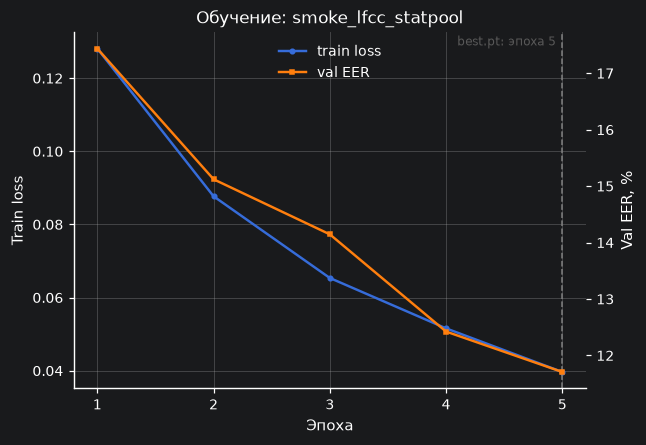

In [2]:
fig = T.plot_training(history, title=f"Обучение: {EXP}")
save_figure(fig, f"{EXP}_training", paths=PATHS)  # вектор (§7)
print("best.pt — эпоха:", T.best_epoch(history))

## Порог равного риска по эпохам

Этот порог Стадия 3 берёт рабочей точкой для «честной» матрицы ошибок. Если он заметно скачет от эпохи к эпохе, значит определён плохо (типично для маленькой валидации, §6.4) — и матрицу на нём надо читать осторожно.

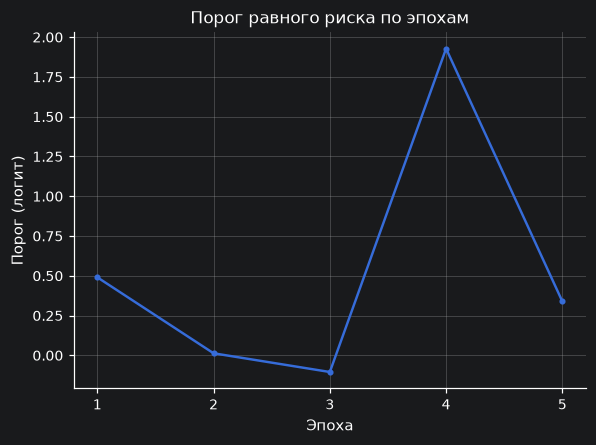

In [3]:
try:
    fig = T.plot_val_threshold(history)
    save_figure(fig, f"{EXP}_val_threshold", paths=PATHS)
except ValueError as e:
    print(e)